In [1]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import classification_report
warnings.filterwarnings("ignore")
os.makedirs("/tmp/mod05", exist_ok=True)
plt.rcParams.update({"figure.dpi":120,"figure.facecolor":"white","axes.spines.top":False,"axes.spines.right":False})
np.random.seed(42)

TRANSFORMERS_OK = False
SENTENCE_TRANS_OK = False

try:
    import torch
    from transformers import AutoTokenizer, AutoModel, pipeline
    TRANSFORMERS_OK = True
    print(f"transformers available| torch {torch.__version__}")
except ImportError:
    print("pip install transformers torch")

try:
    from sentence_transformers import SentenceTransformer
    SENTENCE_TRANS_OK = True
    print("sentence-transformers available")
except ImportError:
    print("pip install sentence-transformers")

transformers available| torch 2.13.0+cpu
sentence-transformers available


In [1]:
import sys
print(sys.executable)

try:
    import sentence_transformers
    print("Version:", sentence_transformers.__version__)

    from sentence_transformers import SentenceTransformer
    print("SentenceTransformer loaded successfully")

except Exception as e:
    print(type(e).__name__)
    print(e)

C:\anaconda\python.exe
Version: 6.0.0
SentenceTransformer loaded successfully


In [2]:
#%pip install transformers torch
#%pip install sentence-transformers

In [2]:
%pip install -U sentence-transformers

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip show sentence-transformers

Name: sentence-transformers
Version: 6.0.0
Summary: Embeddings, Retrieval, and Reranking
Home-page: https://www.SBERT.net
Author: 
Author-email: Nils Reimers <info@nils-reimers.de>, Tom Aarsen <tom.aarsen@huggingface.co>
License-Expression: Apache-2.0
Location: C:\anaconda\Lib\site-packages
Requires: huggingface-hub, numpy, scikit-learn, scipy, tokenizers, torch, tqdm, transformers, typing_extensions
Required-by: 
Note: you may need to restart the kernel to use updated packages.


## BERT Architecture Overview

In [3]:
CLINICAL_SNIPPETS = [
    {"text":"Patient has acute decompensated heart failure, EF 30%, BNP 1450, bilateral pitting edema requiring IV diuresis.",
     "label":"Cardiac","readmitted":1},
    {"text":"STEMI confirmed by EKG, troponin 2.4, activating cath lab for emergency PCI, aspirin and heparin given.",
     "label":"Cardiac","readmitted":1},
    {"text":"Atrial fibrillation with rapid ventricular response, rate controlled with metoprolol, anticoagulation started.",
     "label":"Cardiac","readmitted":0},
    {"text":"COPD exacerbation with diffuse wheezes, albuterol nebs, methylprednisolone, and azithromycin started.",
     "label":"Pulmonary","readmitted":0},
    {"text":"Community-acquired pneumonia, right lower lobe consolidation on CXR, ceftriaxone and azithromycin.",
     "label":"Pulmonary","readmitted":0},
    {"text":"Bilateral pulmonary embolism on CT angiography, RV strain, initiating anticoagulation with rivaroxaban.",
     "label":"Pulmonary","readmitted":1},
    {"text":"Diabetic ketoacidosis, glucose 520, anion gap 24, insulin drip and aggressive IV fluid resuscitation.",
     "label":"Diabetes","readmitted":1},
    {"text":"Uncontrolled T2DM, HbA1c 11.2, intensifying regimen with GLP-1 agonist and SGLT2 inhibitor.",
     "label":"Diabetes","readmitted":0},
    {"text":"Acute kidney injury, creatinine 3.8 from baseline 1.0, holding nephrotoxins, nephrology consulted.",
     "label":"Renal","readmitted":1},
    {"text":"ESRD on hemodialysis, hyperkalemia K 6.4, emergent dialysis performed, access fistula patent.",
     "label":"Renal","readmitted":1},
    {"text":"Septic shock, BP 78/42, norepinephrine initiated, broad-spectrum antibiotics, source investigation.",
     "label":"Sepsis","readmitted":1},
    {"text":"Bacteremia with MSSA, blood cultures positive, transitioning to oxacillin, 6-week course planned.",
     "label":"Sepsis","readmitted":0},
]
df_bert = pd.DataFrame(CLINICAL_SNIPPETS)
print(f"BERT corpus: {len(df_bert)} clinical snippets")
print(df_bert.groupby("label")["readmitted"].value_counts())

BERT corpus: 12 clinical snippets
label      readmitted
Cardiac    1             2
           0             1
Diabetes   0             1
           1             1
Pulmonary  0             2
           1             1
Renal      1             2
Sepsis     0             1
           1             1
Name: count, dtype: int64


## Sentence Embeddings

In [4]:
if SENTENCE_TRANS_OK:
    print("Loading sentence-transformers (all-MiniLM-L6-v2)...")
    print("For clinical work, prefer: Pritamdeka/PubMedBERT-mnli-snli-scinli-scitail-mednli-stsb")
    sbert = SentenceTransformer("all-MiniLM-L6-V2")
    embeddings = sbert.encode(df_bert["text"].tolist(), show_progress_bar=False)
    print(f"Embedding Shape: {embeddings.shape}")
    EMBED_OK=True
else:
    #Fallback: TF IDF + SVD pseudo-embeddings
    print("sentence-transformers not available - using TF-IDF + SVD fallback")
    tfidf = TfidfVectorizer(max_features=500)
    X_sp = tfidf.fit_transform(df_bert["text"])
    svd = TruncatedSVD(n_components=64, random_state=42)
    embeddings = svd.fit_transform(X_sp)
    print(f"Fallback embeddings shape: {embeddings.shape}")
    EMBED_OK = True
    sbert=None

Loading sentence-transformers (all-MiniLM-L6-v2)...
For clinical work, prefer: Pritamdeka/PubMedBERT-mnli-snli-scinli-scitail-mednli-stsb


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding Shape: (12, 384)


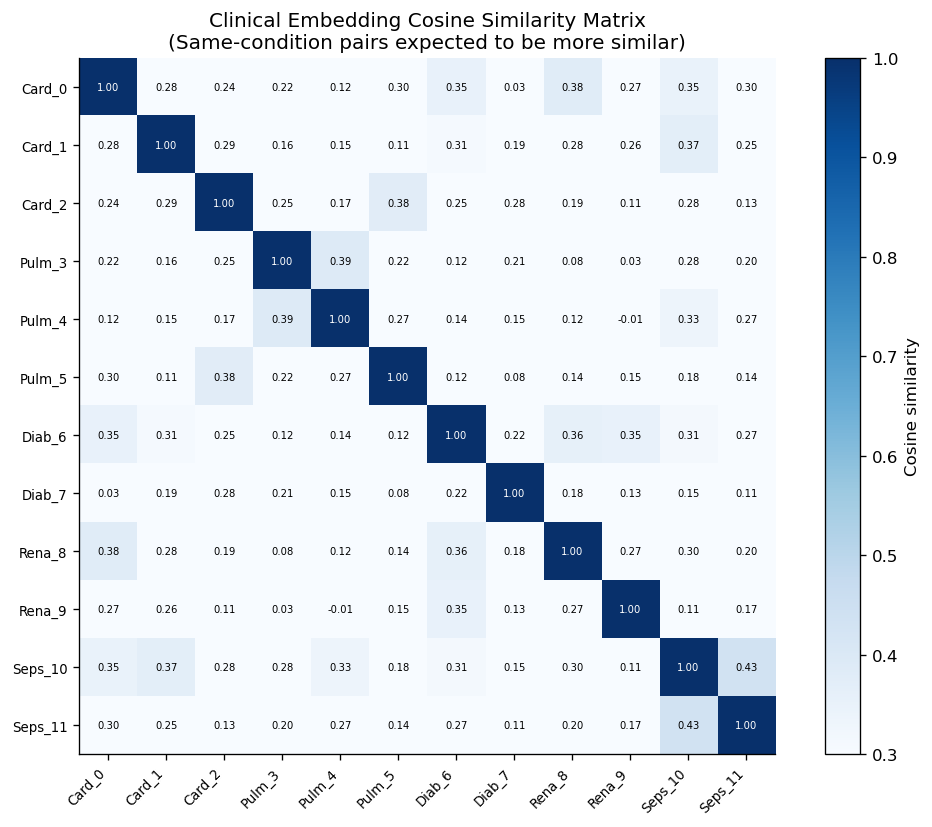

In [5]:
# Cosine similarity matrix
sim_matrix = cosine_similarity(embeddings)
labels_short = [f"{row.label[:4]}_{i}" for i,(_,row) in enumerate(df_bert.iterrows())]

fig, ax = plt.subplots(figsize=(9,7))
im = ax.imshow(sim_matrix, cmap="Blues", vmin=0.3, vmax=1.0)
ax.set_xticks(range(len(labels_short))); ax.set_xticklabels(labels_short, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(labels_short))); ax.set_yticklabels(labels_short, fontsize=8)
plt.colorbar(im, ax=ax, label="Cosine similarity")
ax.set_title("Clinical Embedding Cosine Similarity Matrix\n(Same-condition pairs expected to be more similar)")
for i in range(len(embeddings)):
    for j in range(len(embeddings)):
        ax.text(j,i,f"{sim_matrix[i,j]:.2f}",ha="center",va="center",fontsize=6,
                color="white" if sim_matrix[i,j]>0.75 else "black")
plt.tight_layout()
plt.savefig("/tmp/mod05/bert_similarity.png",bbox_inches="tight"); plt.show()